IMPORT LIBRARIES

In [19]:
import pandas as pd
import numpy as np
import nltk
import string
import pickle

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Load Dataset

The dataset is loaded from a CSV file obtained from Kaggle.

In [20]:
df = pd.read_csv("dataset/mail_data.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Dataset Information

Checking shape, columns and basic information about the dataset.

In [21]:
print(df.shape)

print(df.columns)

df.info()

(5572, 2)
Index(['Category', 'Message'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 542.3 KB


# Spam vs Ham Distribution

In [22]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

# Label Encoding

Converting:
- Ham → 0
- Spam → 1

In [23]:
df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Text Preprocessing Using NLP

Steps:
- Convert text to lowercase
- Remove punctuation
- Remove stopwords

In [24]:
nltk.download('stopwords')
def clean_text(text):

    text = text.lower()

    text = ''.join(
        char
        for char in text
        if char not in string.punctuation
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Naresh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Apply Text Cleaning

In [25]:
df['Message'] = df['Message'].apply(clean_text)

df.head()

,Category,Message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c already say
4,0,nah dont think goes usf lives around though


# TF-IDF Vectorization

Converting text into numerical features.

In [26]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['Message'])

y = df['Category']

print(X.shape)

(5572, 9433)


# Split Dataset

Training Data = 80%
Testing Data = 20%

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Multinomial Naive Bayes Model

In [28]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 9433)","[[0. ,0. ,0. ,...,0.17,1.37,0. ], [0.56,0.26,0.35,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 9433)","[[-9.86,-9.86,-9.86,...,-9.7 ,-9. ,-9.86], [-8.92,-9.13,-9.06,...,-9.36,-9.36,-9.36]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9433


# Model Accuracy

In [29]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.968609865470852


# Classification Report

Evaluating:
- Precision
- Recall
- F1 Score

In [30]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



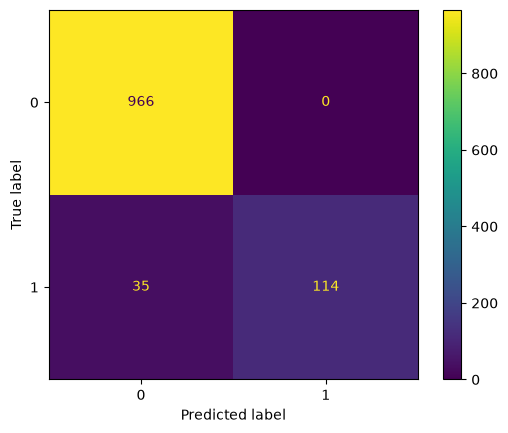

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

# Model Comparison

Comparing Naive Bayes and Logistic Regression.

In [32]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

Logistic Regression Accuracy: 0.9551569506726457


# Best Model Selection

In [33]:
print("Naive Bayes Accuracy:", accuracy)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

if accuracy > lr_accuracy:
    print("Best Model: Multinomial Naive Bayes")
else:
    print("Best Model: Logistic Regression")

Naive Bayes Accuracy: 0.968609865470852
Logistic Regression Accuracy: 0.9551569506726457
Best Model: Multinomial Naive Bayes


# Sample Prediction

In [34]:
msg = [
    "Congratulations! You have won ₹5000. Claim now."
]

msg = tfidf.transform(msg)

prediction = model.predict(msg)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Ham Email")

Spam Email


# Save Trained Model

In [35]:
pickle.dump(
    model,
    open("model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("vectorizer.pkl", "wb")
)

print("Model Saved Successfully!")

Model Saved Successfully!


# Conclusion

The Inbox Intel system successfully classifies emails as Spam or Ham using NLP and Machine Learning techniques.

Final Accuracy:
96.86%

Best Model:
Multinomial Naive Bayes

In [36]:
# 1. First 20 predictions
print("Predictions:")
print(model.predict(X_test[:20]))

# 2. Actual values
print("\nActual Values:")
print(y_test.iloc[:20].values)

# 3. Total spam predictions in test set
print("\nTotal Spam Predictions:")
print(sum(model.predict(X_test)))

# 4. Check spam detection on actual spam messages
spam_count = 0

for msg in df[df['Category'] == 1]['Message'].head(20):
    
    vector = tfidf.transform([msg])
    
    pred = model.predict(vector)
    
    if pred[0] == 1:
        spam_count += 1

print("\nCorrect Spam Predictions out of first 20 spam messages:")
print(spam_count)

# 5. Manual test cases

test_messages = [
    "Congratulations! You have won ₹5000. Claim now.",
    "URGENT! You have won a FREE membership. Call now!",
    "Free entry in a weekly competition.",
    "Meeting scheduled at 10 AM tomorrow.",
    "Project discussion tomorrow at 2 PM."
]

print("\nManual Test Cases:")

for msg in test_messages:

    cleaned = clean_text(msg)

    vector = tfidf.transform([cleaned])

    pred = model.predict(vector)

    print("\nMessage:", msg)
    print("Prediction:", "Spam" if pred[0] == 1 else "Ham")

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]

Actual Values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]

Total Spam Predictions:
114

Correct Spam Predictions out of first 20 spam messages:
16

Manual Test Cases:

Message: Congratulations! You have won ₹5000. Claim now.
Prediction: Spam

Message: URGENT! You have won a FREE membership. Call now!
Prediction: Spam

Message: Free entry in a weekly competition.
Prediction: Spam

Message: Meeting scheduled at 10 AM tomorrow.
Prediction: Ham

Message: Project discussion tomorrow at 2 PM.
Prediction: Ham
